Device: cuda
Batch shapes -> xin: (64, 4, 128, 128)  y: (64, 128, 128)
Fwd pass ok.
=== Training (MSE + physics + IC + BC) — BURGERS ===
Epoch 001 | train_tot=1.389e+00 (data=1.315e-01, phys=9.703e-01, ic=2.803e-01, bc=7.011e-03) | val_mse=7.689e-02 | val_relL2=4.888e-01 | lr=2.0e-03
Epoch 002 | train_tot=4.708e-01 (data=4.319e-02, phys=3.326e-01, ic=8.778e-02, bc=7.237e-03) | val_mse=6.155e-03 | val_relL2=1.434e-01 | lr=2.0e-03
Epoch 003 | train_tot=9.275e-02 (data=3.676e-03, phys=7.605e-02, ic=5.780e-03, bc=7.243e-03) | val_mse=1.684e-03 | val_relL2=7.531e-02 | lr=2.0e-03
Epoch 004 | train_tot=3.968e-02 (data=1.427e-03, phys=2.907e-02, ic=1.993e-03, bc=7.189e-03) | val_mse=7.850e-04 | val_relL2=5.038e-02 | lr=2.0e-03
Epoch 005 | train_tot=2.459e-02 (data=8.249e-04, phys=1.555e-02, ic=1.181e-03, bc=7.035e-03) | val_mse=5.644e-04 | val_relL2=4.309e-02 | lr=2.0e-03
Epoch 006 | train_tot=2.076e-02 (data=6.077e-04, phys=1.238e-02, ic=8.521e-04, bc=6.913e-03) | val_mse=5.299e-04 | val_relL

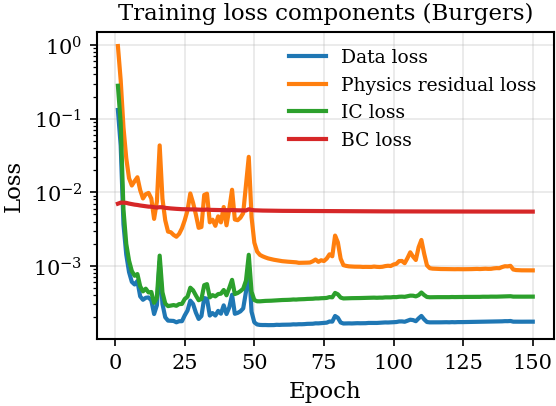

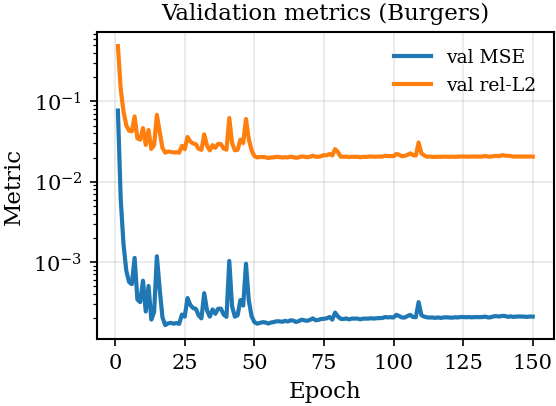

In [ ]:
# ============================
# 1D VISCOUS BURGERS (Periodic x) — FNO2d + Physics-Informed Loss + BC loss
# PDE: u_t + u u_x - nu u_xx = f
# Inputs: [f, X, T, U0]  -> Output: u(t,x)
# ============================
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import os, random

# ------------------ Matplotlib style (Nature-style-ish) ------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2.0,
    "axes.linewidth": 1.0,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

# ------------------ Repro & Device ------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# ------------------ Config (BURGERS) ------------------
Nx, Nt   = 128, 128
Lx       = 2*np.pi
Tfinal   = 1.0
nu       = 5e-2      # viscosity; chosen so solution stays smooth / stable over [0,1]

batch_size = 64
train_samples, val_samples = 1024*4, 32
modes_t, modes_x = 40, 40
width, depth = 64, 4
epochs, lr = 150, 2e-3

# Physics-loss weights
lambda_phys =  1.0      # PDE residual
lambda_ic   =  1.0      # IC consistency at t=0
lambda_bc   =  1.0      # periodic BC consistency in x

CKPT_PATH_MSE  = "fno_burgers1d_pinn_best_mse.pt"
CKPT_PATH_RL2  = "fno_burgers1d_pinn_best_rl2.pt"

# ------------------ Grids & NumPy Derivatives ------------------
def make_grids(Nx, Nt, Lx, Tfinal):
    x = np.linspace(0, Lx, Nx, endpoint=False)
    t = np.linspace(0, Tfinal, Nt, endpoint=True)
    X, T = np.meshgrid(x, t, indexing='xy')  # (Nt,Nx)
    return x, t, X, T

def kvec(Nx, Lx):
    dx = Lx / Nx
    return 2*np.pi * np.fft.fftfreq(Nx, d=dx)

def dx_spectral(u, kx):
    U  = np.fft.fft(u, axis=1)
    dU = (1j * kx[None,:]) * U
    return np.fft.ifft(dU, axis=1).real

def dxx_spectral(u, kx):
    U   = np.fft.fft(u, axis=1)
    ddU = (-(kx[None,:]**2)) * U
    return np.fft.ifft(ddU, axis=1).real

def dt_finite(u, t):
    Nt = u.shape[0]
    ut = np.zeros_like(u)
    ut[1:-1] = (u[2:] - u[:-2]) / (t[2:,None] - t[:-2,None])
    ut[0]    = (u[1] - u[0])   / (t[1] - t[0])
    ut[-1]   = (u[-1] - u[-2]) / (t[-1] - t[-2])
    return ut

# ------------------ Manufactured fields ------------------
def manufactured_u(X, T, seed=None, Kx=5, Kt=3, kx_max=6, wt_max=6,
                   a_spatial=(0.05, 0.35), a_time=(0.2, 1.0), target_std=0.5):
    """
    u(x,t) = sum_{i=1..Kx} sum_{j=1..Kt} A_i * B_j * sin(k_i x + phi_i) * sin(w_j t + psi_j)
    Periodic in x; smooth in t.
    """
    rng  = np.random.default_rng(seed)
    kset = rng.integers(1, kx_max+1, size=Kx)
    wset = rng.integers(1, wt_max+1, size=Kt)
    A    = rng.uniform(*a_spatial, size=Kx) * rng.choice([-1,1], size=Kx)
    B    = rng.uniform(*a_time,   size=Kt) * rng.choice([-1,1], size=Kt)
    phi  = rng.uniform(0, 2*np.pi, size=Kx)
    psi  = rng.uniform(0, 2*np.pi, size=Kt)

    u = np.zeros_like(X, dtype=float)
    for ki, Ai, ph in zip(kset, A, phi):
        sx = np.sin(ki*X + ph)
        for wj, Bj, ps in zip(wset, B, psi):
            st = np.sin(wj*T + ps)
            u += Ai * Bj * sx * st

    u = u - u.mean()
    std = u.std()
    if std > 1e-8:
        u *= (target_std/std)
    return u

# ------------------ Dataset (BURGERS) ------------------
class Burgers1DManufacturedDataset(Dataset):
    """
    PDE: u_t + u u_x - nu u_xx = f
    We manufacture u(x,t), then compute f := u_t + u u_x - nu u_xx.
    """
    def __init__(self, n_samples, Nx, Nt, Lx, Tfinal, nu):
        self.n = n_samples
        self.x, self.t, self.X, self.T = make_grids(Nx, Nt, Lx, Tfinal)
        self.kx = kvec(Nx, Lx)
        self.nu = nu
        self.data = []

        for i in range(n_samples):
            u   = manufactured_u(self.X, self.T, seed=SEED + i)
            ut  = dt_finite(u, self.t)          # time derivative
            ux  = dx_spectral(u, self.kx)       # spatial derivative
            uxx = dxx_spectral(u, self.kx)      # second derivative
            f   = ut + u*ux - self.nu * uxx     # from PDE: u_t + u u_x - nu u_xx = f

            u0 = u[0:1, :]                      # IC row
            U0 = np.tile(u0, (Nt, 1))           # broadcast in time

            inp = np.stack([f, self.X, self.T, U0], axis=0).astype(np.float32)  # [4,Nt,Nx]
            out = u.astype(np.float32)                                          # [Nt,Nx]
            self.data.append((inp, out))

    def __len__(self): return self.n
    def __getitem__(self, i):
        x, y = self.data[i]
        return torch.from_numpy(x), torch.from_numpy(y)

# ------------------ FNO blocks (unchanged) ------------------
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.modes1       = modes1
        self.modes2       = modes2
        scale = 1.0 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(scale * torch.randn(
            in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(
            in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        B, C, H, W = x.shape            # H ~ Nt, W ~ Nx
        x_ft = torch.fft.rfft2(x, norm="ortho")
        out_ft = torch.zeros(B, self.out_channels, H, W//2+1,
                             device=x.device, dtype=torch.cfloat)
        Hm = min(self.modes1, H)
        Wm = min(self.modes2, W//2 + 1)
        out_ft[:, :, :Hm, :Wm]   = self.compl_mul2d(x_ft[:, :, :Hm, :Wm], self.weights1[:, :, :Hm, :Wm])
        out_ft[:, :, -Hm:, :Wm]  = self.compl_mul2d(x_ft[:, :, -Hm:, :Wm], self.weights2[:, :, :Hm, :Wm])
        x = torch.fft.irfft2(out_ft, s=(H, W), norm="ortho")
        return x

class FNO2d(nn.Module):
    def __init__(self, in_channels, out_channels, width, modes1, modes2, depth=4):
        super().__init__()
        self.width  = width
        self.depth  = depth
        self.fc0    = nn.Conv2d(in_channels, width, 1)
        self.fourier = nn.ModuleList([SpectralConv2d(width, width, modes1, modes2) for _ in range(depth)])
        self.w       = nn.ModuleList([nn.Conv2d(width, width, 1) for _ in range(depth)])
        self.act     = nn.GELU()
        self.fc1     = nn.Conv2d(width, width, 1)
        self.fc2     = nn.Conv2d(width, out_channels, 1)

    def forward(self, x):
        x = self.fc0(x)
        for i in range(self.depth):
            y = self.fourier[i](x)
            x = self.act(y + self.w[i](x))
        x = self.act(self.fc1(x))
        x = self.fc2(x)
        return x

# ------------------ Torch Physics Helpers (BURGERS) ------------------
def torch_kvec(Nx, Lx, device):
    dx  = Lx / Nx
    kx  = 2*np.pi * np.fft.fftfreq(Nx, d=dx)
    return torch.tensor(kx, dtype=torch.float32, device=device)  # [Nx]

def torch_dx_spectral(u, kx):
    """
    u: [B,Nt,Nx] real -> u_x: [B,Nt,Nx] real (periodic spectral first derivative in x)
    """
    U   = torch.fft.fft(u, dim=-1)
    dU  = (1j * kx)[None, None, :] * U
    ux  = torch.fft.ifft(dU, dim=-1).real
    return ux

def torch_dxx_spectral(u, kx):
    """
    u: [B,Nt,Nx] real -> u_xx: [B,Nt,Nx] real
    """
    U   = torch.fft.fft(u, dim=-1)
    ddU = (-(kx**2))[None, None, :] * U
    uxx = torch.fft.ifft(ddU, dim=-1).real
    return uxx

def torch_dt_cdiff(u, t):
    """
    u: [B,Nt,Nx], t: [Nt] (torch or numpy)
    returns u_t: [B,Nt,Nx] (centered interior, one-sided at ends)
    """
    if not torch.is_tensor(t):
        t = torch.tensor(t, dtype=torch.float32, device=u.device)
    ut = torch.zeros_like(u)
    ut[:,1:-1,:] = (u[:,2:,:] - u[:,:-2,:]) / (t[2:].view(1,-1,1) - t[:-2].view(1,-1,1))
    ut[:,0,:]    = (u[:,1,:]   - u[:,0,:])   / (t[1] - t[0])
    ut[:,-1,:]   = (u[:,-1,:]  - u[:,-2,:])  / (t[-1] - t[-2])
    return ut

def physics_residual_burgers(pred_phys, xin_phys, nu, kx, t_vec):
    """
    pred_phys: [B,Nt,Nx] predicted u (physical)
    xin_phys : [B,4,Nt,Nx] with channel 0 = f (physical)
    PDE: u_t + u u_x - nu u_xx = f
    returns R = u_t + u u_x - nu u_xx - f  [B,Nt,Nx]
    """
    f_phys = xin_phys[:,0]                         # [B,Nt,Nx]
    ut     = torch_dt_cdiff(pred_phys, t_vec)      # [B,Nt,Nx]
    ux     = torch_dx_spectral(pred_phys, kx)      # [B,Nt,Nx]
    uxx    = torch_dxx_spectral(pred_phys, kx)     # [B,Nt,Nx]
    R      = ut + pred_phys*ux - nu*uxx - f_phys
    return R

# ------------------ Plotting utils ------------------
def plot_heatmap(field, X, T, title, xlabel="x", ylabel="t", cmap="coolwarm"):
    plt.figure(figsize=(4.0, 3.0))
    extent = [X.min(), X.max(), T.min(), T.max()]
    im = plt.imshow(field, aspect='auto', origin='lower', extent=extent, cmap=cmap)
    plt.xlabel(xlabel); plt.ylabel(ylabel); plt.title(title)
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(width=0.8, length=3)
    plt.tight_layout()
    plt.show()

def plot_time_slice_grid(x, t, kinds, pred_dict, ref_dict,
                         t_indices, t_labels):
    """
    Multi-panel figure:
      rows = time slices
      cols = IC types
      Each panel: Exact vs FNO.
    """
    nrows = len(t_indices)
    ncols = len(kinds)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3.0*ncols, 2.4*nrows),
                             sharex=True, sharey=False)

    if nrows == 1:
        axes = np.array([axes])
    if ncols == 1:
        axes = axes[:, np.newaxis]

    for ci, kind in enumerate(kinds):
        u_ref  = ref_dict[kind]
        u_pred = pred_dict[kind]
        for ri, (tidx, lbl) in enumerate(zip(t_indices, t_labels)):
            ax = axes[ri, ci]
            ax.plot(x, u_ref[tidx],  linestyle="-",  color="C0", linewidth=3.2, label="Exact")
            ax.plot(x, u_pred[tidx], linestyle="--", color="C1", linewidth=3.0, label="FNO")
            if ri == nrows-1:
                ax.set_xlabel(r"$x$")
            if ci == 0:
                ax.set_ylabel(r"$u(x,t)$")
            if ri == 0:
                ax.set_title(f"IC: {kind}")
            ax.text(0.98, 0.98, lbl,
                    transform=ax.transAxes,
                    fontsize=9, ha="right", va="top")
            ax.grid(alpha=0.2, linewidth=0.8)

    # One legend for the whole figure
    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc="upper center", ncol=2,
               frameon=False, bbox_to_anchor=(0.5, 1.02))
    plt.tight_layout()
    plt.show()

# ------------------ Build data ------------------
x, t, X, T = make_grids(Nx, Nt, Lx, Tfinal)
train_set  = Burgers1DManufacturedDataset(train_samples, Nx, Nt, Lx, Tfinal, nu)
val_set    = Burgers1DManufacturedDataset(val_samples,   Nx, Nt, Lx, Tfinal, nu)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print("Batch shapes -> xin:", tuple(xb.shape), " y:", tuple(yb.shape))

# ------------------ Init model ------------------
model = FNO2d(in_channels=4, out_channels=1, width=width,
              modes1=modes_t, modes2=modes_x, depth=depth).to(device)
with torch.no_grad():
    _ = model(xb.to(device).float())
print("Fwd pass ok.")

# ------------------ Eval helper (physical metrics) ------------------
def evaluate(model, loader, device):
    model.eval()
    mse_fn = nn.MSELoss(reduction="mean")
    tot_mse, tot_rl2, n = 0.0, 0.0, 0
    with torch.no_grad():
        for xin, y in loader:
            xin = xin.to(device).float()          # [B,4,Nt,Nx]
            y   = y.to(device).unsqueeze(1).float()  # [B,1,Nt,Nx]
            pred = model(xin)                        # [B,1,Nt,Nx]
            mse = mse_fn(pred, y).item()
            num = torch.linalg.vector_norm((pred - y).reshape(pred.size(0), -1), dim=1)
            den = torch.linalg.vector_norm(y.reshape(y.size(0), -1), dim=1) + 1e-12
            rl2 = (num/den).mean().item()
            bs = xin.size(0)
            tot_mse += mse * bs; tot_rl2 += rl2 * bs; n += bs
    return tot_mse/max(n,1), tot_rl2/max(n,1)

# ------------------ Train: MSE + λ_phys*||R||² + λ_ic*||u(0)-U0||² + λ_bc*||u(.,0)-u(.,Lx)||² ------------------
def train_fno_pinn(model, train_loader, val_loader,
                   epochs=epochs, lr=lr, device=device,
                   Lx=Lx, Tfinal=Tfinal, nu=nu,
                   lambda_phys=lambda_phys, lambda_ic=lambda_ic, lambda_bc=lambda_bc):
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=30)
    mse   = nn.MSELoss()

    # torch grids for physics terms
    kx    = torch_kvec(Nx, Lx, device)
    t_vec = torch.tensor(np.linspace(0, Tfinal, Nt, endpoint=True),
                         dtype=torch.float32, device=device)

    best = {
        "val_mse": float("inf"),
        "val_rl2": float("inf"),
        "epoch_mse": -1,
        "epoch_rl2": -1,
    }

    # ---- history containers ----
    history = {
        "data":   [],
        "phys":   [],
        "ic":     [],
        "bc":     [],
        "tot":    [],
        "val_mse": [],
        "val_rl2": []
    }

    for ep in range(1, epochs+1):
        model.train()
        running = {"data":0.0, "phys":0.0, "ic":0.0, "bc":0.0, "tot":0.0, "n":0}

        for xin_phys, y_phys in train_loader:
            xin_phys = xin_phys.to(device).float()               # [B,4,Nt,Nx]
            y_phys   = y_phys.to(device).unsqueeze(1).float()    # [B,1,Nt,Nx]

            # ---------------- Data loss ----------------
            pred = model(xin_phys)                               # [B,1,Nt,Nx]
            data_loss = mse(pred, y_phys)

            # ---------------- Physics residual loss ----------------
            pred_u = pred.squeeze(1)                             # [B,Nt,Nx]
            R = physics_residual_burgers(pred_u, xin_phys, nu, kx, t_vec)
            phys_loss = torch.mean(R * R)

            # ---------------- IC loss (t = 0) ----------------
            U0_line = xin_phys[:, 3, 0, :]                       # [B,Nx]
            ic_loss = torch.mean((pred_u[:, 0, :] - U0_line)**2)

            # ---------------- BC loss (periodic in x) ----------------
            left_vals  = pred_u[:, :, 0]                         # [B,Nt]
            right_vals = pred_u[:, :, -1]                        # [B,Nt]
            bc_loss = torch.mean((left_vals - right_vals)**2)

            # ---------------- Total loss ----------------
            loss = (data_loss
                    + lambda_phys * phys_loss
                    + lambda_ic   * ic_loss
                    + lambda_bc   * bc_loss)

            opt.zero_grad()
            loss.backward()
            opt.step()

            # ---------------- Bookkeeping ----------------
            B = xin_phys.size(0)
            running["data"] += data_loss.detach().item() * B
            running["phys"] += phys_loss.detach().item() * B
            running["ic"]   += ic_loss.detach().item()   * B
            running["bc"]   += bc_loss.detach().item()   * B
            running["tot"]  += loss.detach().item()      * B
            running["n"]    += B

        # ---------------- Per-epoch averages ----------------
        n = max(running["n"], 1)
        epoch_data = running["data"] / n
        epoch_phys = running["phys"] / n
        epoch_ic   = running["ic"]   / n
        epoch_bc   = running["bc"]   / n
        epoch_tot  = running["tot"]  / n

        # ---------------- Validation ----------------
        val_mse, val_rl2 = evaluate(model, val_loader, device)
        sched.step(val_mse)

        # ---- store in history ----
        history["data"].append(epoch_data)
        history["phys"].append(epoch_phys)
        history["ic"].append(epoch_ic)
        history["bc"].append(epoch_bc)
        history["tot"].append(epoch_tot)
        history["val_mse"].append(val_mse)
        history["val_rl2"].append(val_rl2)

        print(f"Epoch {ep:03d} | "
              f"train_tot={epoch_tot:.3e} "
              f"(data={epoch_data:.3e}, phys={epoch_phys:.3e}, "
              f"ic={epoch_ic:.3e}, bc={epoch_bc:.3e}) | "
              f"val_mse={val_mse:.3e} | val_relL2={val_rl2:.3e} | "
              f"lr={opt.param_groups[0]['lr']:.1e}")

        # ---- Best by val MSE ----
        if val_mse < best["val_mse"]:
            best["val_mse"]   = val_mse
            best["epoch_mse"] = ep
            torch.save({
                "model_state": model.state_dict(),
                "epoch": ep,
                "val_mse": val_mse,
                "val_rl2": val_rl2,
                "criterion": "val_mse",
                "config": {
                    "Nx": Nx, "Nt": Nt, "Lx": Lx, "Tfinal": Tfinal,
                    "nu": nu, "modes_t": modes_t, "modes_x": modes_x,
                    "width": width, "depth": depth,
                    "lambda_phys": lambda_phys,
                    "lambda_ic": lambda_ic,
                    "lambda_bc": lambda_bc,
                }},
                CKPT_PATH_MSE)

        # ---- Best by val rel-L2 ----
        if val_rl2 < best["val_rl2"]:
            best["val_rl2"]   = val_rl2
            best["epoch_rl2"] = ep
            torch.save({
                "model_state": model.state_dict(),
                "epoch": ep,
                "val_mse": val_mse,
                "val_rl2": val_rl2,
                "criterion": "val_rl2",
                "config": {
                    "Nx": Nx, "Nt": Nt, "Lx": Lx, "Tfinal": Tfinal,
                    "nu": nu, "modes_t": modes_t, "modes_x": modes_x,
                    "width": width, "depth": depth,
                    "lambda_phys": lambda_phys,
                    "lambda_ic": lambda_ic,
                    "lambda_bc": lambda_bc,
                }},
                CKPT_PATH_RL2)

    print(f"Best val_mse={best['val_mse']:.3e} @ epoch {best['epoch_mse']}")
    print(f"Best val_relL2={best['val_rl2']:.3e} @ epoch {best['epoch_rl2']}")

    return history

def plot_training_losses(history):
    epochs = np.arange(1, len(history["tot"]) + 1)

    plt.figure(figsize=(4.0, 3.0))
    plt.plot(epochs, history["data"], label="Data loss")
    plt.plot(epochs, history["phys"], label="Physics residual loss")
    plt.plot(epochs, history["ic"],   label="IC loss")
    plt.plot(epochs, history["bc"],   label="BC loss")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training loss components (Burgers)")
    plt.grid(alpha=0.3, linewidth=0.8)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

def plot_val_metrics(history):
    epochs = np.arange(1, len(history["val_mse"]) + 1)

    plt.figure(figsize=(4.0, 3.0))
    plt.plot(epochs, history["val_mse"], label="val MSE")
    plt.plot(epochs, history["val_rl2"], label="val rel-L2")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.title("Validation metrics (Burgers)")
    plt.grid(alpha=0.3, linewidth=0.8)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

print("=== Training (MSE + physics + IC + BC) — BURGERS ===")
history = train_fno_pinn(model, train_loader, val_loader)
plot_training_losses(history)
plot_val_metrics(history)

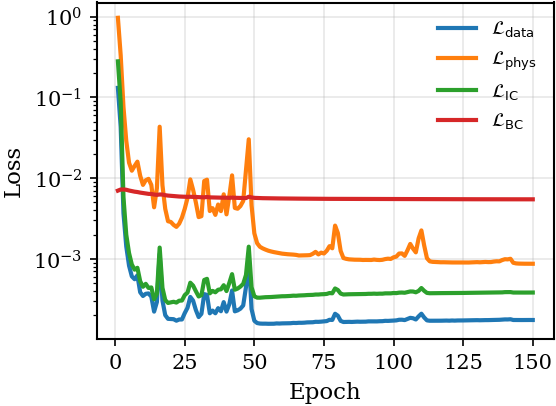

In [ ]:
def plot_training_losses(history):
    epochs = np.arange(1, len(history["tot"]) + 1)

    plt.figure(figsize=(4.0, 3.0))

    plt.plot(epochs, history["data"], label=r"$\mathcal{L}_{\text{data}}$")
    plt.plot(epochs, history["phys"], label=r"$\mathcal{L}_{\text{phys}}$")
    plt.plot(epochs, history["ic"],   label=r"$\mathcal{L}_{\text{IC}}$")
    plt.plot(epochs, history["bc"],   label=r"$\mathcal{L}_{\text{BC}}$")

    plt.yscale("log")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    # plt.title("Training loss components")
    plt.grid(alpha=0.3, linewidth=0.8)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


# Plot the different components on the same figure
plot_training_losses(history)


=== Inference (BURGERS): f=0, IC='sine' ===


/usr/local/lib/python3.12/dist-packages/torch/functional.py:422: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:233.)
  return _VF.einsum(equation, operands)  # type: ignore[attr-defined]


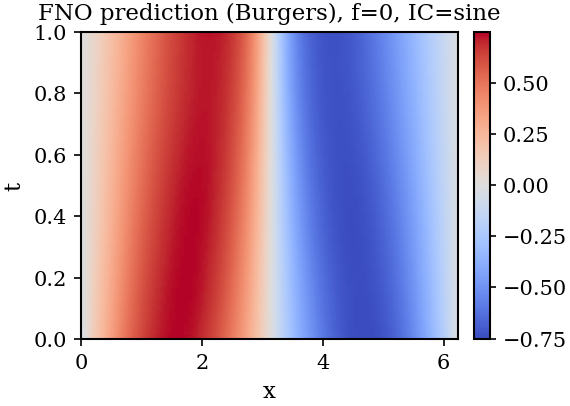

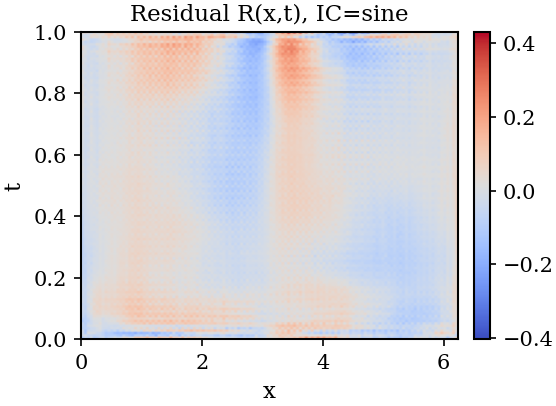

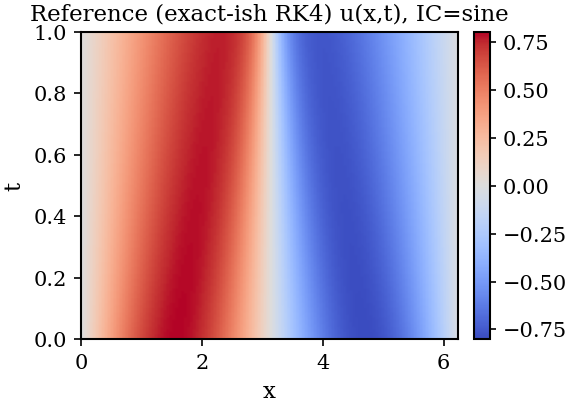

Ref comparison: MSE=8.998e-04 | rel-L2=5.447e-02

=== Inference (BURGERS): f=0, IC='two_mode' ===


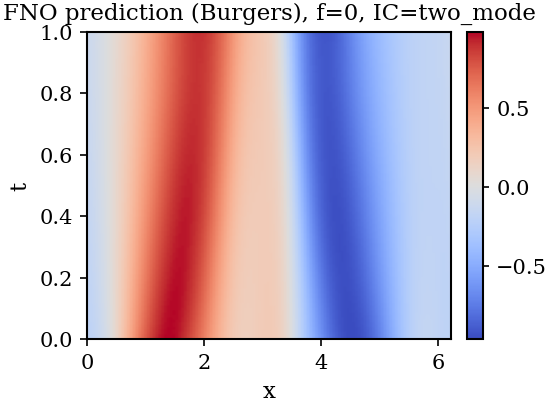

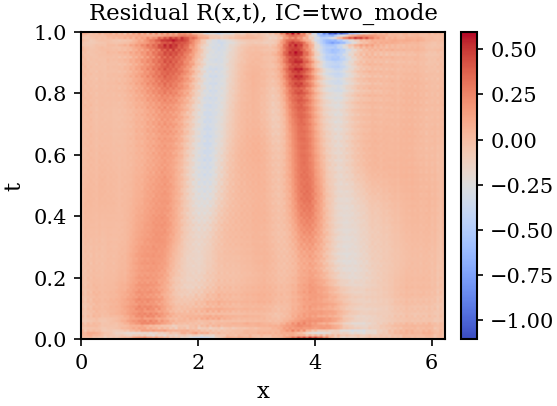

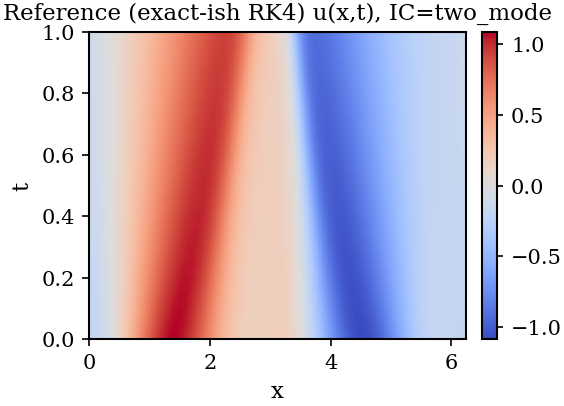

Ref comparison: MSE=4.678e-03 | rel-L2=1.189e-01

=== Inference (BURGERS): f=0, IC='three_mode' ===


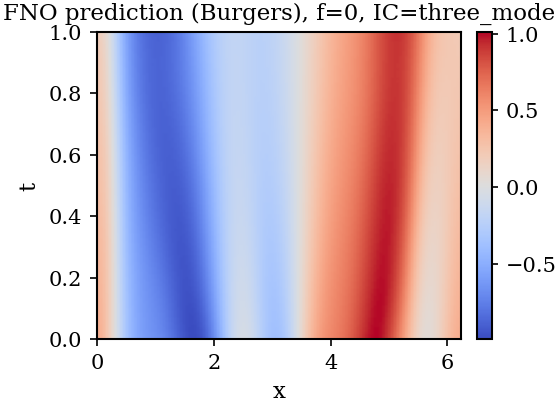

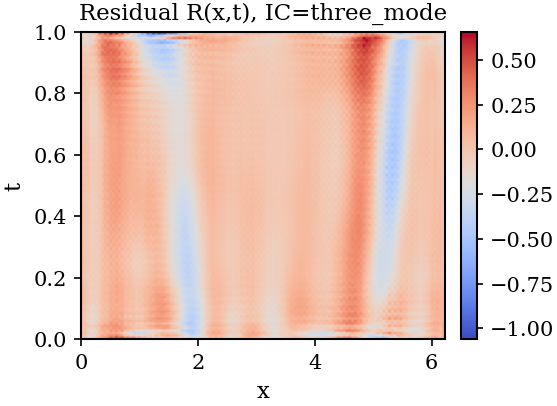

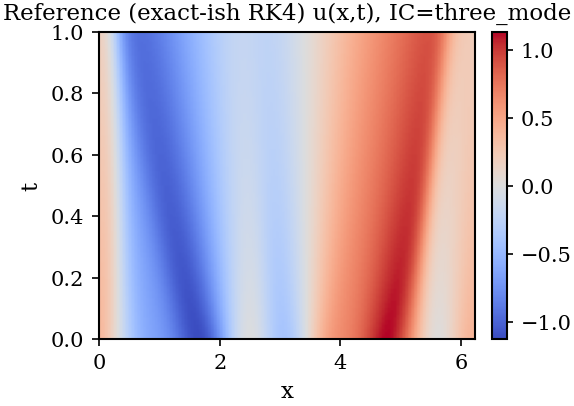

Ref comparison: MSE=5.351e-03 | rel-L2=1.259e-01


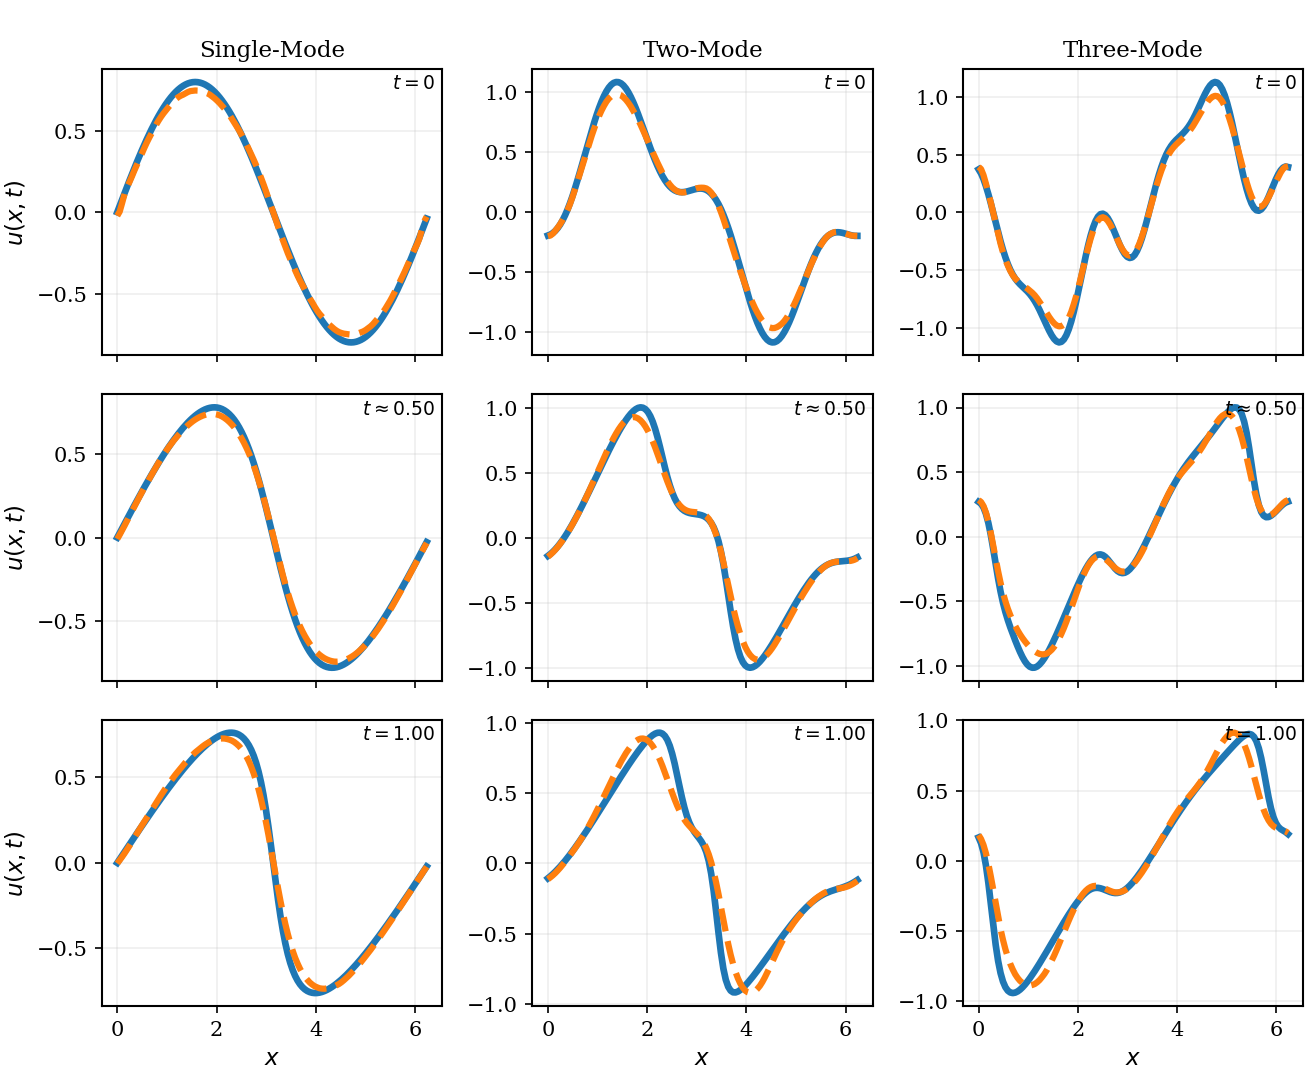

In [ ]:
# ------------------ Inference utilities ------------------
def u0_fn(x, kind="two_mode"):
    if kind == "sine":
        return 0.8*np.sin(x)
    elif kind == "two_mode":
        return 0.8*np.sin(x) - 0.3*np.sin(3*x + 0.7)
    elif kind == "three_mode":
        return -0.8*np.sin(x) + 0.3*np.sin(3*x + 0.7) - 0.2*np.sin(5*x - 1.1)
    else:
        raise ValueError("unknown kind")

def burgers_reference(u0_row, nu, Nx, Nt, Lx, Tfinal):
    """
    Reference spectral RK4 solver for viscous Burgers with f=0:
    u_t + u u_x - nu u_xx = 0, periodic in x.
    """
    x = np.linspace(0, Lx, Nx, endpoint=False)
    t = np.linspace(0, Tfinal, Nt, endpoint=True)
    dt = t[1] - t[0]
    kx = kvec(Nx, Lx)

    def rhs(u):
        ux  = dx_spectral(u[None, :], kx)[0]
        uxx = dxx_spectral(u[None, :], kx)[0]
        return -u * ux + nu * uxx

    u = np.zeros((Nt, Nx), dtype=float)
    u[0] = u0_row.copy()

    for n in range(Nt-1):
        un = u[n]
        k1 = rhs(un)
        k2 = rhs(un + 0.5*dt*k1)
        k3 = rhs(un + 0.5*dt*k2)
        k4 = rhs(un + dt*k3)
        u[n+1] = un + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

    return u

# ------------------ Load best (by MSE) & test on f=0 ------------------
eval_model = FNO2d(in_channels=4, out_channels=1, width=width,
                   modes1=modes_t, modes2=modes_x, depth=depth).to(device)
ckpt = torch.load(CKPT_PATH_MSE, map_location=device)
eval_model.load_state_dict(ckpt["model_state"])
eval_model.eval()

kinds = ["sine", "two_mode", "three_mode"]
pred_dict = {}
ref_dict  = {}

for kind in kinds:
    print(f"\n=== Inference (BURGERS): f=0, IC='{kind}' ===")
    x, t, X, T = make_grids(Nx, Nt, Lx, Tfinal)
    u0_row = u0_fn(x, kind=kind)
    U0     = np.tile(u0_row[None,:], (Nt,1))
    f_zero = np.zeros((Nt, Nx), dtype=np.float32)
    inp_np = np.stack([f_zero, X, T, U0], axis=0).astype(np.float32)  # [4,Nt,Nx]
    inp = torch.from_numpy(inp_np)[None].to(device)

    with torch.no_grad():
        pred = eval_model(inp).squeeze().detach().cpu().numpy()  # [Nt,Nx]

    # store for multi-IC comparison later
    pred_dict[kind] = pred
    u_ref = burgers_reference(u0_row, nu, Nx, Nt, Lx, Tfinal)
    ref_dict[kind]  = u_ref

    # Heatmap of prediction
    plot_heatmap(pred, X, T, title=f"FNO prediction (Burgers), f=0, IC={kind}")

    # Physics residual: R = u_t + u u_x - nu u_xx (since f=0 at inference)
    kx_np = kvec(Nx, Lx)
    ut  = dt_finite(pred, t)
    ux  = dx_spectral(pred, kx_np)
    uxx = dxx_spectral(pred, kx_np)
    res = ut + pred*ux - nu*uxx
    plot_heatmap(res, X, T, title=f"Residual R(x,t), IC={kind}")

    # Reference heatmap
    plot_heatmap(u_ref, X, T, title=f"Reference (exact-ish RK4) u(x,t), IC={kind}")

    mse = np.mean((pred - u_ref)**2)
    relL2 = np.linalg.norm((pred - u_ref).ravel()) / (np.linalg.norm(u_ref.ravel()) + 1e-12)
    print("Ref comparison: MSE=%.3e | rel-L2=%.3e" % (mse, relL2))

# ------------------ Multi-IC, multi-time comparison plot ------------------
t_indices = [0, Nt//2, Nt-1]
t_labels  = [r"$t = 0$", rf"$t \approx {Tfinal/2:.2f}$", rf"$t = {Tfinal:.2f}$"]
plot_time_slice_grid(x, t, kinds, pred_dict, ref_dict, t_indices, t_labels)

In [ ]:
def plot_3x4_summary(x, t, X, T, kinds, pred_dict, ref_dict):
    """
    3 x 4 figure:
      rows  = initial conditions
      cols:
        1) u(x,0)
        2) Exact solution
        3) FNO prediction
        4) Difference (pred - exact)
    """

    # Map kind -> label
    kind_label = {
        "sine":       "Single-Mode",
        "two_mode":   "Two-Mode",
        "three_mode": "Three-Mode",
    }

    nrows = len(kinds)
    ncols = 4
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3.2*ncols, 2.4*nrows),
                             sharex=False, sharey=False)

    if nrows == 1:
        axes = np.array([axes])

    # ---------- Global color scale ----------
    all_true = np.concatenate([ref_dict[k].ravel() for k in kinds])
    all_pred = np.concatenate([pred_dict[k].ravel() for k in kinds])
    u_min = min(all_true.min(), all_pred.min())
    u_max = max(all_true.max(), all_pred.max())

    all_diff = np.concatenate([(pred_dict[k] - ref_dict[k]).ravel() for k in kinds])
    diff_max = np.max(np.abs(all_diff))

    extent = [x.min(), x.max(), t.min(), t.max()]

    # ---------- Column titles ----------
    col_titles = [
        r"$u(x,0)$",
        r"Exact : $u_{\mathrm{ref}}(x,t)$",
        r"FNO : $u_{\theta}(x,t)$",
        r"Error : $u_{\theta}-u_{\mathrm{ref}}$"
    ]
    for ci, title in enumerate(col_titles):
        axes[0, ci].set_title(title)

    # ---------- Fill the grid ----------
    for ri, kind in enumerate(kinds):

        u_ref  = ref_dict[kind]
        u_pred = pred_dict[kind]

        # (1) IC line plot
        ax_ic = axes[ri, 0]
        ax_ic.plot(x, u_ref[0], color="k")
        ax_ic.grid(alpha=0.3, linewidth=0.8)
        if ri == nrows - 1:
            ax_ic.set_xlabel(r"$x$")
        ax_ic.set_ylabel(kind_label[kind], fontsize=11)

        # (2) Exact solution
        ax_true = axes[ri, 1]
        im_true = ax_true.imshow(u_ref, aspect='auto', origin='lower',
                                 extent=extent, cmap="coolwarm",
                                 vmin=u_min, vmax=u_max)
        if ri == nrows - 1:
            ax_true.set_xlabel(r"$x$")
        ax_true.set_ylabel(r"$t$")
        fig.colorbar(im_true, ax=ax_true, fraction=0.046, pad=0.04)

        # (3) FNO prediction
        ax_pred = axes[ri, 2]
        im_pred = ax_pred.imshow(u_pred, aspect='auto', origin='lower',
                                 extent=extent, cmap="coolwarm",
                                 vmin=u_min, vmax=u_max)
        if ri == nrows - 1:
            ax_pred.set_xlabel(r"$x$")
        ax_pred.set_yticklabels([])
        fig.colorbar(im_pred, ax=ax_pred, fraction=0.046, pad=0.04)

        # (4) Difference
        diff = u_pred - u_ref
        ax_diff = axes[ri, 3]
        im_diff = ax_diff.imshow(diff, aspect='auto', origin='lower',
                                 extent=extent, cmap="bwr",
                                 vmin=-diff_max, vmax=diff_max)
        if ri == nrows - 1:
            ax_diff.set_xlabel(r"$x$")
        ax_diff.set_yticklabels([])
        fig.colorbar(im_diff, ax=ax_diff, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


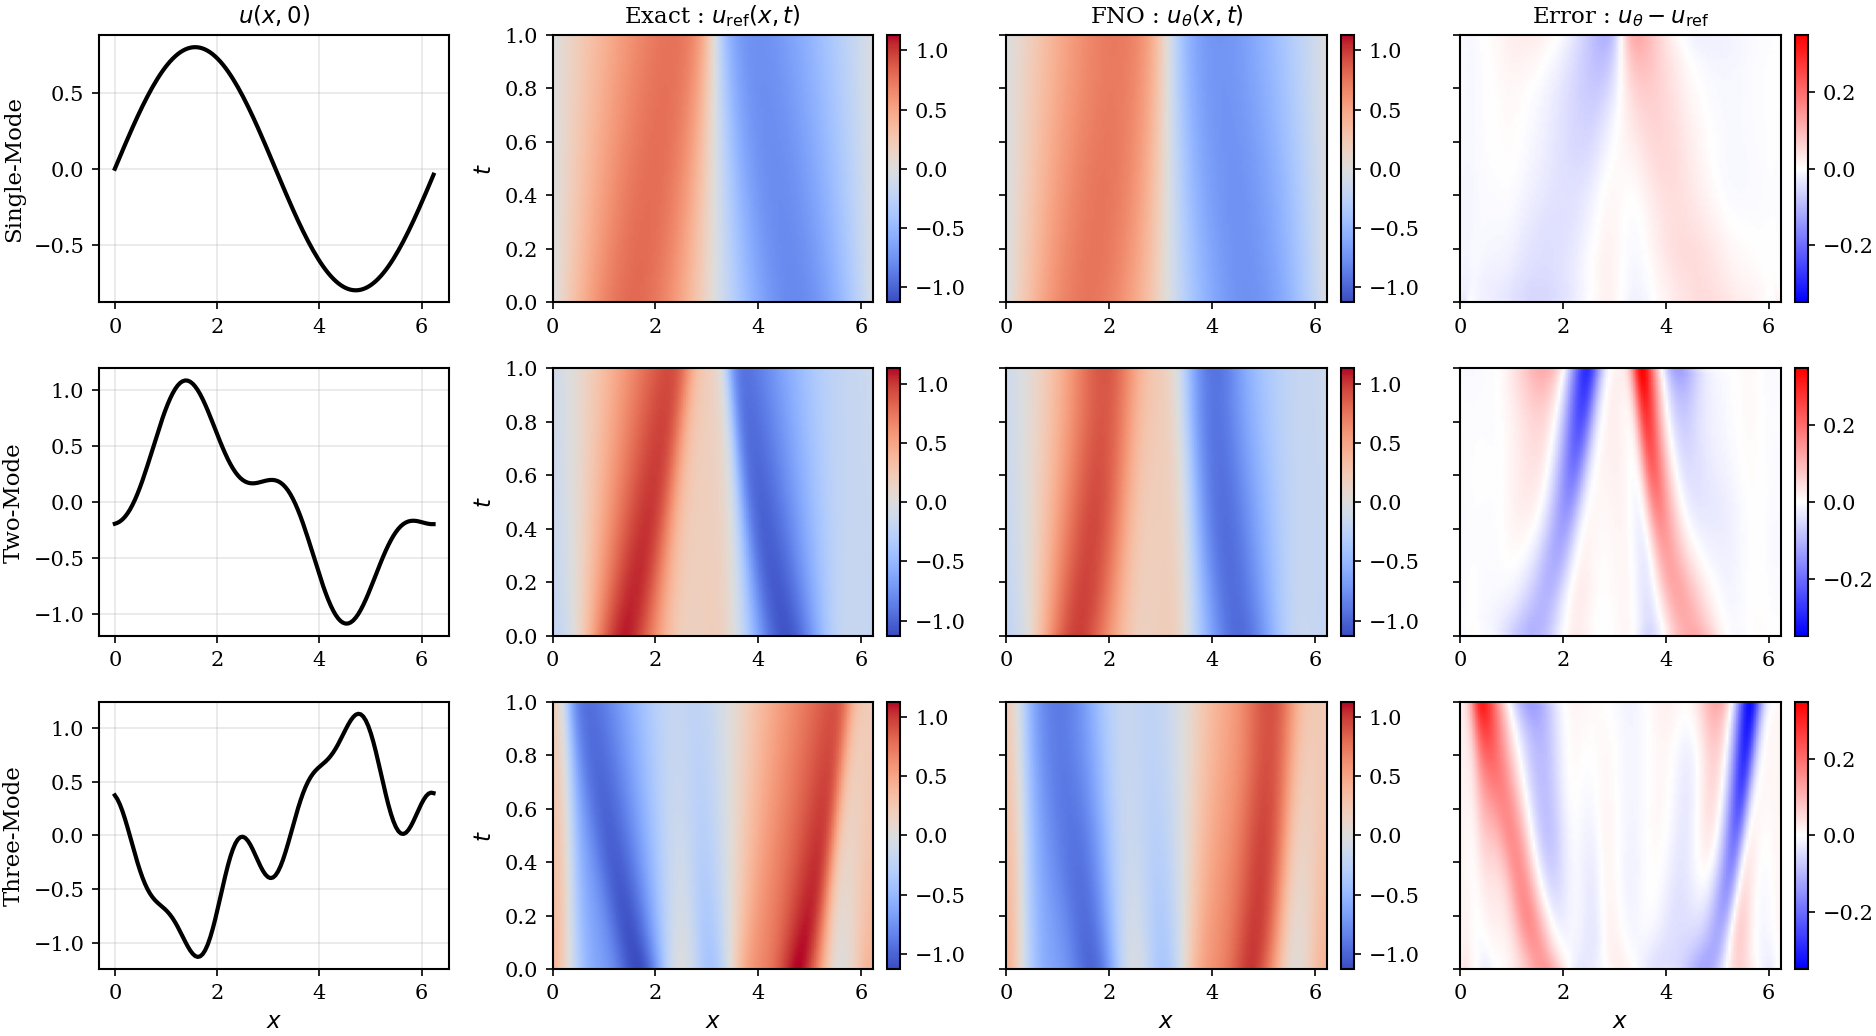

In [ ]:
# After the loop over kinds where you filled pred_dict[kind] and ref_dict[kind]
plot_3x4_summary(x, t, X, T, kinds, pred_dict, ref_dict)


In [ ]:
def plot_time_slice_grid(x, t, kinds, pred_dict, ref_dict,
                         t_indices, t_labels):
    """
    Multi-panel figure:
      rows = time slices
      cols = IC types (Single-Mode / Two-Mode / Three-Mode)
      Each panel auto-scales its own ylim,
      EXCEPT the last column, which is fixed to [-1.1, 1.1].
      Time labels (t = ...) appear in top-right.
    """

    kind_label = {
        "sine":       "Single-Mode",
        "two_mode":   "Two-Mode",
        "three_mode": "Three-Mode",
    }

    nrows = len(t_indices)
    ncols = len(kinds)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.0*ncols, 2.4*nrows),
        sharex=True,
        sharey=False
    )

    if nrows == 1:
        axes = np.array([axes])
    if ncols == 1:
        axes = axes[:, np.newaxis]

    # ---------- Column titles ----------
    for ci, kind in enumerate(kinds):
        axes[0, ci].set_title(kind_label.get(kind, kind))

    # ---------- Plotting ----------
    for ci, kind in enumerate(kinds):
        u_ref  = ref_dict[kind]
        u_pred = pred_dict[kind]

        for ri, (tidx, lbl_t) in enumerate(zip(t_indices, t_labels)):
            ax = axes[ri, ci]

            # Exact
            ax.plot(
                x, u_ref[tidx],
                linestyle="-",
                color="C0",
                linewidth=3.2,
                label="Exact" if (ri == 0 and ci == 0) else None
            )

            # FNO
            ax.plot(
                x, u_pred[tidx],
                linestyle="--",
                color="C1",
                linewidth=3.0,
                label="FNO" if (ri == 0 and ci == 0) else None
            )

            # x-label last row
            if ri == nrows - 1:
                ax.set_xlabel(r"$x$")

            # y-label first column
            if ci == 0:
                ax.set_ylabel(r"$u(x,t)$")

            # ---------- Time label at TOP-RIGHT ----------
            ax.text(
                0.98, 0.98,
                lbl_t,
                transform=ax.transAxes,
                fontsize=9,
                ha="right",
                va="top"
            )

            # ---------- Fix ylim for LAST column ----------
            if ci == ncols - 1:
                ax.set_ylim(-1.3, 1.3)

            ax.grid(alpha=0.2, linewidth=0.8)

    # ---------- Global legend ----------
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc="upper center", ncol=2,
               frameon=False,
               bbox_to_anchor=(0.5, 1.02))

    plt.tight_layout()
    plt.show()


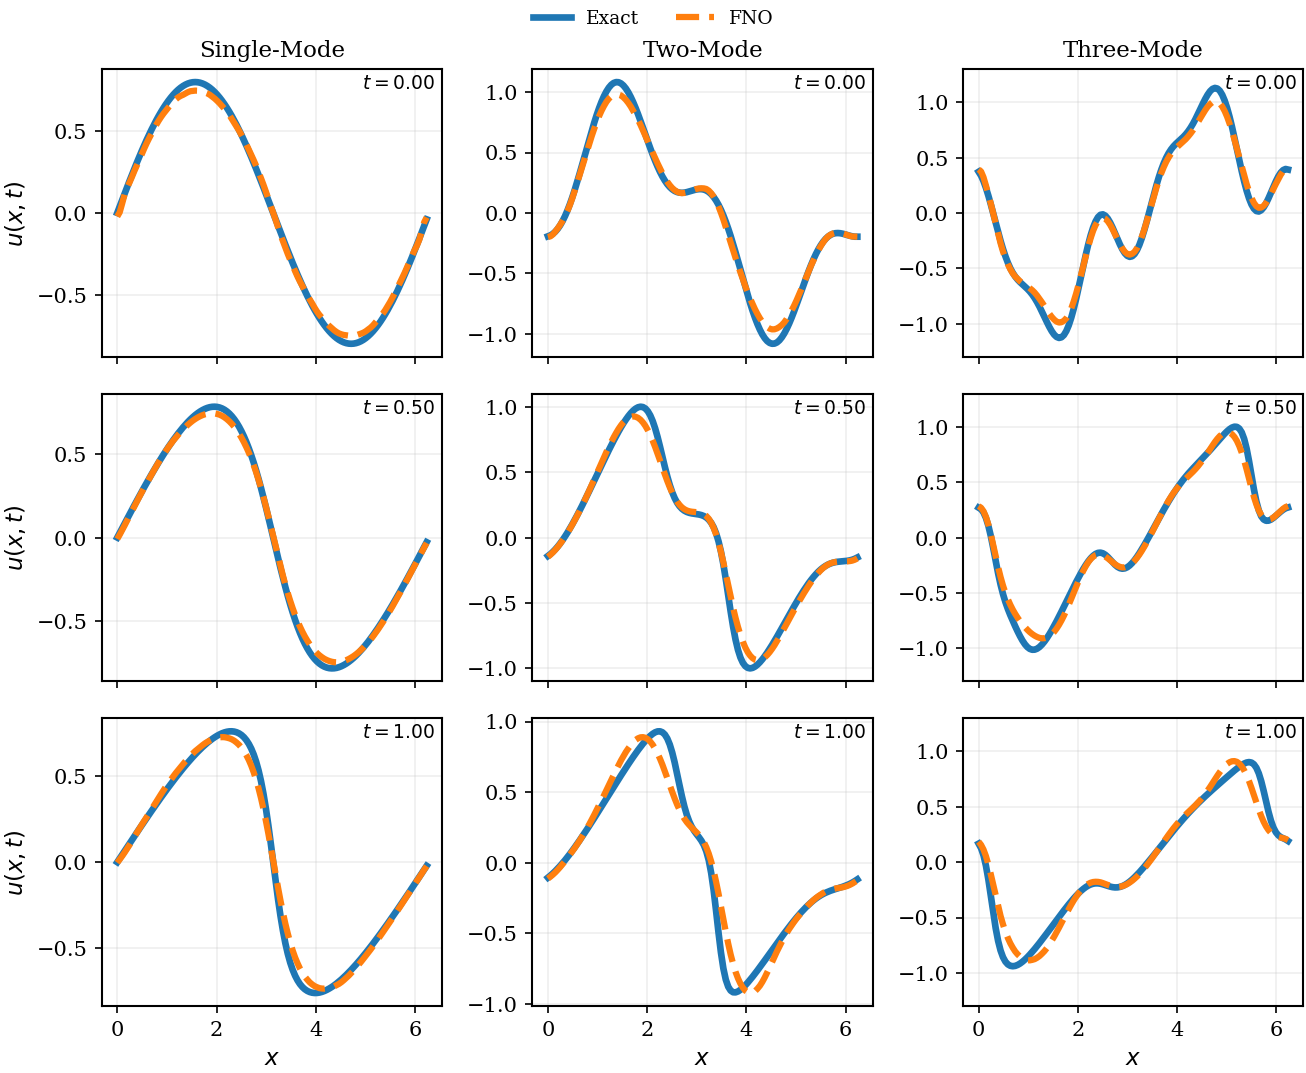

In [ ]:
# Choose time indices for slice plots, including t ≈ 0.75
idx_0     = 0
idx_mid   = Nt // 2

t_target  = 0.75 * Tfinal       # here Tfinal = 1.0
idx_075   = int(np.argmin(np.abs(t - t_target)))
idx_final = Nt - 1

t_indices = [idx_0, idx_mid, idx_final]
t_labels  = [rf"$t = {t[idx_0]:.2f}$",
             rf"$t = {t[idx_mid]:.2f}$",
             rf"$t = {t[idx_final]:.2f}$"]

plot_time_slice_grid(x, t, kinds, pred_dict, ref_dict, t_indices, t_labels)

